# **Sam's Club vs Walmart Price Comparison Analysis**
This project uses Python to compare product prices between Sam's Club and Walmart to determine which store offers better value for consumers.

## **1. Import Libraries and Load Dataset**
In this section, the required libraries are imported and the dataset is loaded into Python for analysis.

In [2]:
import pandas as pd
df = pd.read_csv("dataset.csv")
df.head()

,Items,Store,Package size,Unit,Price ($)
0,Chicken breast,Sam's Club,5.69,lbs,16.39
1,Chicken breast,Walmart,1.92,lbs,9.93
2,Pastur raised eggs,Sam's Club,18.00,count,5.87
3,Pastur raised eggs,Walmart,12.00,count,7.46
4,Golden star prime jasmine rice,Sam's Club,8.00,lbs,9.98


## **2. Data Cleaning**
The column names are cleaned by removing spaces and converting text to lowercase. This helps prevent coding errors.

In [3]:
# make sure columns are clean
df.columns = df. columns. str.strip().str.lower()

## **3. Calculate Price Per Unit**
Price per unit is calculated by dividing total price by package size. This allows fair comparison between different product sizes.

In [4]:
# make sure price_per_unit exists
df['price_per_unit' ] = df['price ($)' ] / df['package size' ]

# find cheapest store per item
cheapest = df.loc[df.groupby('items' ) ['price_per_unit']. idxmin() ]

# show result
cheapest[['items', 'store', 'price_per_unit' ]]

,items,store,price_per_unit
40,Aveeno body wash,Sam's Club,0.287576
14,Barilla spagetti,Sam's Club,1.420000
12,Broccoli,Sam's Club,1.635000
24,Built puff protein bars,Sam's Club,1.533846
0,Chicken breast,Sam's Club,2.880492
36,Colgate toothpaste,Sam's Club,0.532667
34,ECOS hypoallergenic detergent,Sam's Club,0.085190
16,Extra virgin olive oil,Sam's Club,0.257059
4,Golden star prime jasmine rice,Sam's Club,1.247500
32,Granulated sugar,Sam's Club,0.658000


## **4. Store Price Comparison**
Products sold in both stores are compared to identify which store offers lower unit prices.

In [7]:
df.columns = df. columns. str.strip() . str. lower()
df['price_per_unit' ] = df ['price ($)' ] / df['package size' ]

valid_items = df.groupby('items' ) ['store' ]. nunique()
valid_items = valid_items[valid_items >= 2].index
df_filtered = df[df['items'].isin(valid_items)]

comparison = df_filtered. pivot_table(
index='items',
columns='store',
values='price_per_unit')

comparison. columns = comparison.columns. str.strip() . str. lower()

comparison['difference' ] = comparison['walmart'] - comparison["sam's club"]

comparison. reset_index()

store,items,sam's club,walmart,difference
0,Aveeno body wash,0.287576,0.393030,0.105455
1,Barilla spagetti,1.420000,1.840000,0.420000
2,Broccoli,1.635000,3.293333,1.658333
3,Built puff protein bars,1.533846,2.245000,0.711154
4,Chicken breast,2.880492,5.171875,2.291383
5,Colgate toothpaste,0.532667,0.703922,0.171255
6,ECOS hypoallergenic detergent,0.085190,0.104364,0.019173
7,Extra virgin olive oil,0.257059,0.442604,0.185545
8,Golden star prime jasmine rice,1.247500,1.985000,0.737500
9,Granulated sugar,0.658000,1.708571,1.050571


## **5. Individual vs Family Spending Analysis**
Total spending is estimated for an individual shopper and a family shopper to compare suitability.

In [8]:
# make sure columns are clean
df.columns = df. columns. str.strip() . str. lower()

# make sure required column exists
df['price_per_unit' ] = df['price ($)' ] / df['package size' ]

# simulate consumption
individual_qty = 1
family_qty = 5

df['individual_cost' ] = df['price_per_unit' ] * individual_qty
df['family_cost' ] = df['price_per_unit'] * family_qty

# group by store (Lowercase!)
individual_total = df.groupby('store') ['individual_cost'].sum()
family_total = df.groupby('store' ) ['family_cost' ].sum()

print("Individual spending:\n", individual_total)
print("\nFamily spending: \n", family_total)

Individual spending:
 store
Sam's Club    25.237347
Walmart       40.074222
Name: individual_cost, dtype: float64

Family spending: 
 store
Sam's Club    126.186735
Walmart       200.371110
Name: family_cost, dtype: float64


## **6. Membership Fee Impact**
Sam's Club membership fee is added to determine whether savings still remain after additional costs.

In [9]:
df['store' ] = df['store']. str.strip() . str.lower()

individual_qty = 1
family_qty = 5

df['individual_cost'] = df['price_per_unit' ] * individual_qty
df['family_cost'] = df['price_per_unit'] * family_qty

individual_total = df.groupby('store' ) ['individual_cost' ].sum()
family_total = df.groupby('store') ['family_cost'].sum()

membership_fee = 60 # annual fee

individual_total_with_fee = individual_total. copy()
family_total_with_fee = family_total.copy()

# add fee ONLY to sam's club
individual_total_with_fee["sam's club"] += membership_fee
family_total_with_fee["sam's club"] += membership_fee

print(" === WITHOUT membership === ")
print("Individual:\n", individual_total)
print("\nFamily: \n", family_total)

print("\n === WITH membership === ")
print("Individual:\n", individual_total_with_fee)
print("\nFamily:\n", family_total_with_fee)

 === WITHOUT membership === 
Individual:
 store
sam's club    25.237347
walmart       40.074222
Name: individual_cost, dtype: float64

Family: 
 store
sam's club    126.186735
walmart       200.371110
Name: family_cost, dtype: float64

 === WITH membership === 
Individual:
 store
sam's club    85.237347
walmart       40.074222
Name: individual_cost, dtype: float64

Family:
 store
sam's club    186.186735
walmart       200.371110
Name: family_cost, dtype: float64


## **7. Savings Visualisation**
A bar chart is used to show percentage savings from buying products at Sam's Club instead of Walmart.

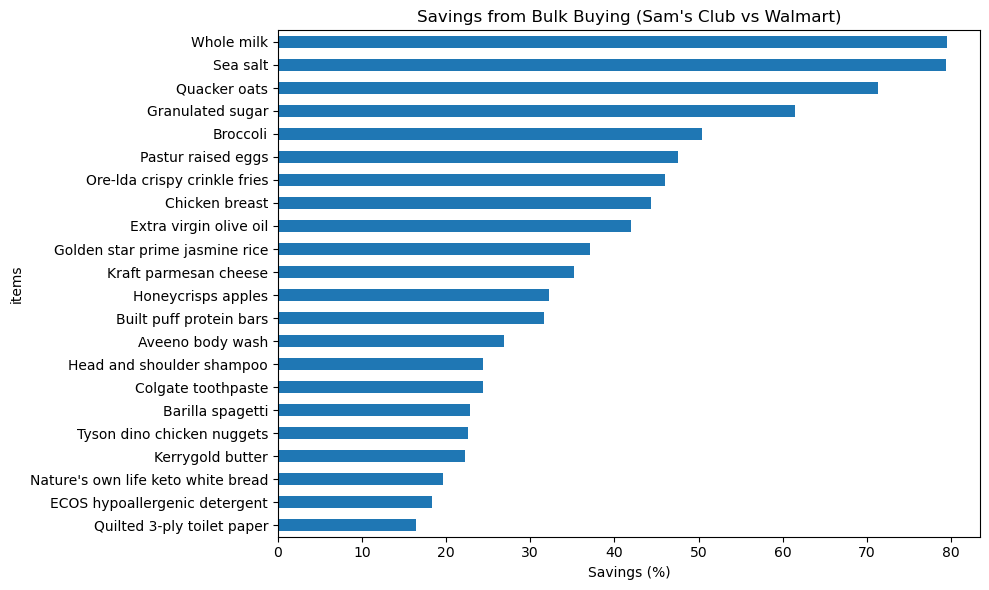

In [11]:
import matplotlib.pyplot as plt

# make sure savings exists
comparison['savings_%' ] = (
(comparison['walmart'] - comparison["sam's club"]) / comparison['walmart' ]
) * 100

# sort for nicer graph
comparison_sorted = comparison. sort_values('savings_%' )

# horizontal bar chart (best for readability)
comparison_sorted['savings_%' ].plot(kind='barh', figsize=(10,6))

plt.xlabel("Savings (%)")
plt.title("Savings from Bulk Buying (Sam's Club vs Walmart)")

plt.tight_layout()
plt.show()

## **8. Conclusion**
- Walmart is more suitable for smaller or occasional purchases.
- Sam's Club offers better long-term value for families and bulk buyers.
- Python helped automate calculations and support data-driven.

In [12]:
comparison['savings_%' ] = (
(comparison['walmart' ] - comparison["sam's club"]) / comparison['walmart' ]
) * 100

comparison

store,sam's club,walmart,difference,savings_,savings_%
items,,,,,
Aveeno body wash,0.287576,0.393030,0.105455,26.831149,26.831149
Barilla spagetti,1.420000,1.840000,0.420000,22.826087,22.826087
Broccoli,1.635000,3.293333,1.658333,50.354251,50.354251
Built puff protein bars,1.533846,2.245000,0.711154,31.677231,31.677231
Chicken breast,2.880492,5.171875,2.291383,44.304685,44.304685
Colgate toothpaste,0.532667,0.703922,0.171255,24.328691,24.328691
ECOS hypoallergenic detergent,0.085190,0.104364,0.019173,18.371495,18.371495
Extra virgin olive oil,0.257059,0.442604,0.185545,41.921202,41.921202
Golden star prime jasmine rice,1.247500,1.985000,0.737500,37.153652,37.153652


## **9. Data Source**
The dataset was created manually using price comparisons between Sam's Club and Walmart.

Alternatively, the data was collected from:
- Sam's Club website
- Walmart website